In [ ]:
%load_ext pretty_jupyter

## Introduction - Loading Data

This walkthrough is part of the [ECLR](https://datasquad.github.io/ECLR/) page.

Here we will demonstrate how to load data into Python. In Python, we can load data either from a file on our local system or directly from an online database. This walkthrough demonstrates both techniques using Python.

## Preparing your workspace

As usual we begin a notebook or scriptfile by loading the libraries we anticipate to use.

In [100]:
# Importing the os module
import os
import pandas as pd
import numpy as np
from lets_plot import *
# Lets_plot requires a setup
LetsPlot.setup_html()

Later in this workthrough we will use a few more libraries/packages and we will import them then, when we introduce them. If you already know which packages you will use, it is easiest to add them to your list here.

## File upload

When working with an existing data file in a Jupyter Notebook (or script file), you need to ensure that the file is located in the current working directory or specify its full path. For example, if you have saved [mroz.csv](https://github.com/datasquad/ECLR/blob/gh-pages/data/Mroz.csv) in a folder named `C:\Pycode`, then you can change your working directory to that folder using the `os` module and the command below should read `os.chdir("C:\Pycode")`. 

In [8]:
# Set your working directory
os.chdir("C:/Pycode")  # Replace with your drive and path

# Check the current working directory
print("Current Working Directory:", os.getcwd())


Current Working Directory: C:\Pycode


> Remember that the  `os.getcwd()` gets the current working directory and tells you which folder Python currently uses as its default location for reading or saving files.

The data file we practice with here is a Comma-Separated Values (CSV) file. To load such a file in Python, we use the `read_csv` function from the `pandas` library, assuming that the data file is in the working directory:

In [12]:
# Load the CSV file
mydata = pd.read_csv("Mroz.csv")

If this worked, you should now be able to see an object called `mydata` in your list of variables.

> A typical **error message** you could receive here is "FileNotFoundError: [Errno 2] No such file or directory: 'Mroz.csv'". If you get this message the most likely reason is that the file `Mroz.csv` is not in the place where Python is looking. Either it is not in the working directory, or you did not set the working directory correctly. 

Remember that you can use the following functions to get some guidance in the use of this function:

- Use the `help()` function to view detailed documentation.
- Use the `?` or `??` syntax in Jupyter Notebook for quick insights or to explore the source code.

An example could be:

In [16]:
# Get help for read_csv, any of these will access help
#help(pd.read_csv)
pd.read_csv?
#pd.read_csv??

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    sep=<no_default>,
    delimiter=None,
    header='infer',
    names=<no_default>,
    index_col=None,
    usecols=None,
    squeeze=None,
    prefix=<no_default>,
    mangle_dupe_cols=True,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters=None,
    true_values=None,
    false_values=None,
    skipinitialspace=False,
    skiprows=None,
    skipfooter=0,
    nrows=None,
    na_values=None,
    keep_default_na=True,
    na_filter=True,
    verbose=False,
    skip_blank_lines=True,
    parse_dates=None,
    infer_datetime_format=False,
    keep_date_col=False,
    date_parser=None,
    dayfirst=False,
    cache_dates=True,
    iterator=False,
    chunksize=None,
    compression: 'CompressionOptions' = 'infer',
    thousands=None,
    decimal: 'str' = '.',
    lineterminator=None,
    quotechar='"',
    quoting=0,
    doublequote=True,
    esc

The `pd.read_csv()` function reads the csv file and creates a DataFrame (a table-like structure) in Python. 

Now, let's load the datafile again after correcting the error:

In Python's Jupyter Notebook, you have several options to explore and understand your data, helping you get a good "sense" of the dataset you're working with. These tools provide insights into the structure, content, and summary statistics of your data. Let's start by getting a first glimpse at the data using the `info()` function:

In [17]:
# Display structure and types of columns
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   inlf      753 non-null    int64  
 1   hours     753 non-null    int64  
 2   kidslt6   753 non-null    int64  
 3   kidsge6   753 non-null    int64  
 4   age       753 non-null    int64  
 5   educ      753 non-null    int64  
 6   wage      753 non-null    object 
 7   repwage   753 non-null    float64
 8   hushrs    753 non-null    int64  
 9   husage    753 non-null    int64  
 10  huseduc   753 non-null    int64  
 11  huswage   753 non-null    float64
 12  faminc    753 non-null    int64  
 13  mtr       753 non-null    float64
 14  motheduc  753 non-null    int64  
 15  fatheduc  753 non-null    int64  
 16  unem      753 non-null    float64
 17  city      753 non-null    int64  
 18  exper     753 non-null    int64  
 19  nwifeinc  753 non-null    float64
 20  lwage     753 non-null    object

The `info()` function provides a concise summary of the DataFrame, including: 
- The number of rows and columns.
- Column names and their data types.
- Number of non-missing values in each column

The dataset has **753  observations (rows)** and **22 columns (variables)**. Most of the data are recognised as numerical data types, such as `int64` (for integer values) and `float64` (for decimal values). However, you can see that two columns, namely `wage` and `lwage`are recognised as `objects`, which is Python's generic type for non-numeric data (e.g., strings or mixed types). **Why didn't Python recognise `wage` and `lwage` as numeric?**

As we explore our data we can see that the `wage` column and therefore the `lwage` column contain observations which do not have a number but rather a `"."`. This is this spreadsheet’s way of telling you that for these observations there is no wage information. The information is missing. Different spreadsheets code missing values in different ways. Sometimes it will just be empty cells; sometimes it will say `“NA”` or `“na”`. You need to help Python to recognise missing values. That is what the `na_values="."` option in the `read_csv` function does.

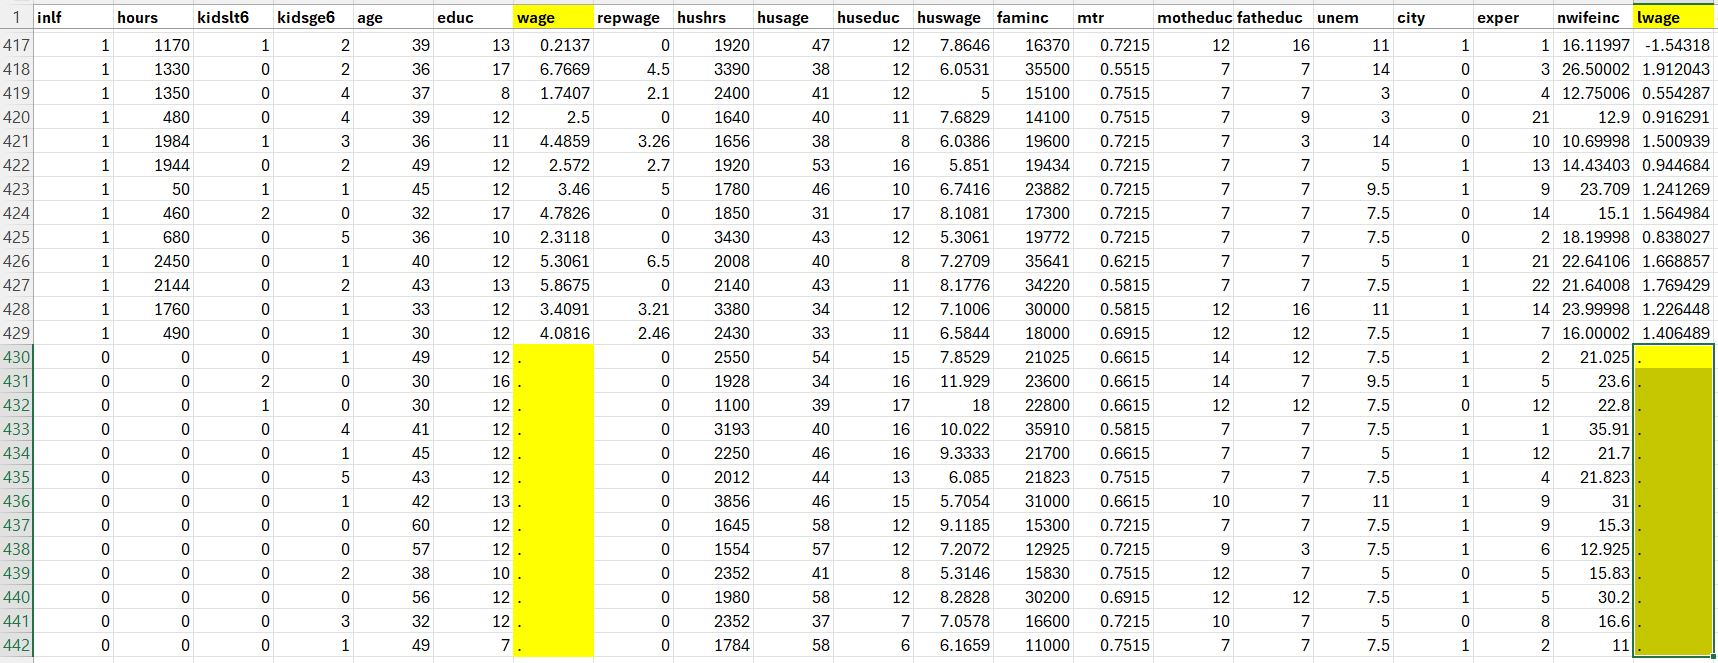

In [18]:
# Handle missing data
mydata = pd.read_csv("Mroz.csv", na_values=".")

# Verify the updated column types
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   inlf      753 non-null    int64  
 1   hours     753 non-null    int64  
 2   kidslt6   753 non-null    int64  
 3   kidsge6   753 non-null    int64  
 4   age       753 non-null    int64  
 5   educ      753 non-null    int64  
 6   wage      428 non-null    float64
 7   repwage   753 non-null    float64
 8   hushrs    753 non-null    int64  
 9   husage    753 non-null    int64  
 10  huseduc   753 non-null    int64  
 11  huswage   753 non-null    float64
 12  faminc    753 non-null    int64  
 13  mtr       753 non-null    float64
 14  motheduc  753 non-null    int64  
 15  fatheduc  753 non-null    int64  
 16  unem      753 non-null    float64
 17  city      753 non-null    int64  
 18  exper     753 non-null    int64  
 19  nwifeinc  753 non-null    float64
 20  lwage     428 non-null    float6

The `na_values="."` tells pandas to interpret cells with `"."` as missing values (`NaN`) in the DataFrame. After reloading the dataset, `mydata.info()` will show the updated data types, where observations in `wage` and `lwage` previously containing `"."` will now have missing values (`NaN`) and be treated as numerical data.

To check the updated dataset, we can use the `iloc[]` function, which allows us to slice the data in Python and display specific rows. In this case, we want to select rows 430 through 440. See this [walkthrough](https://datasquad.github.io/ECLR/Py_coding/Py_BasicCode.html#Subsetting) for more advice on how to access particular subsets of your data.

In [21]:
# Check rows 425 to 430, note Python starts counting at 0, and does not include the last referenced row
mydata.iloc[425:431]

,inlf,hours,kidslt6,kidsge6,age,educ,wage,repwage,hushrs,husage,...,faminc,mtr,motheduc,fatheduc,unem,city,exper,nwifeinc,lwage,expersq
425,1,2144,0,2,43,13,5.8675,0.00,2140,43,...,34220,0.5815,7,7,7.5,1,22,21.64008,1.769429,484
426,1,1760,0,1,33,12,3.4091,3.21,3380,34,...,30000,0.5815,12,16,11.0,1,14,23.99998,1.226448,196
427,1,490,0,1,30,12,4.0816,2.46,2430,33,...,18000,0.6915,12,12,7.5,1,7,16.00002,1.406489,49
428,0,0,0,1,49,12,NaN,0.00,2550,54,...,21025,0.6615,14,12,7.5,1,2,21.02500,NaN,4
429,0,0,2,0,30,16,NaN,0.00,1928,34,...,23600,0.6615,14,7,9.5,1,5,23.60000,NaN,25
430,0,0,1,0,30,12,NaN,0.00,1100,39,...,22800,0.6615,12,12,7.5,0,12,22.80000,NaN,144


You can now observe that the observations in `wage` and `lwage`, which previously contained `"."` (e.g. rows 428 to 430), have been replaced with missing values (`NaN`). This allows these columns to be correctly treated as numerical data.

However, what if your data comes as an excel file, such as [mroz.xlsx](https://datasquad.github.io/ECLR/Data/mroz.xlsx)? In this case, you can use the `read_excel` function (assuming that yo downloaded that file into your working directory).

In [24]:
# Load an Excel file
mydata_excel = pd.read_excel("Mroz.xlsx", na_values=".")

# Display rows 425 to 430 to confirm that NaNs were recognised 
mydata_excel.iloc[425:431]

,inlf,hours,kidslt6,kidsge6,age,educ,wage,repwage,hushrs,husage,...,faminc,mtr,motheduc,fatheduc,unem,city,exper,nwifeinc,lwage,expersq
425,1,2144,0,2,43,13,5.8675,0.00,2140,43,...,34220,0.5815,7,7,7.5,1,22,21.64008,1.769429,484
426,1,1760,0,1,33,12,3.4091,3.21,3380,34,...,30000,0.5815,12,16,11.0,1,14,23.99998,1.226448,196
427,1,490,0,1,30,12,4.0816,2.46,2430,33,...,18000,0.6915,12,12,7.5,1,7,16.00002,1.406489,49
428,0,0,0,1,49,12,NaN,0.00,2550,54,...,21025,0.6615,14,12,7.5,1,2,21.02500,NaN,4
429,0,0,2,0,30,16,NaN,0.00,1928,34,...,23600,0.6615,14,7,9.5,1,5,23.60000,NaN,25
430,0,0,1,0,30,12,NaN,0.00,1100,39,...,22800,0.6615,12,12,7.5,0,12,22.80000,NaN,144


The csv file (`Mroz.csv`) you downloaded earlier can also be accessed directly from a place on the internet. On this occasion you get this if you click on the `Raw` button on [this page](https://github.com/datasquad/ECLR/blob/gh-pages/data/Mroz.csv) You then get to this page (https://raw.githubusercontent.com/datasquad/ECLR/refs/heads/gh-pages/data/Mroz.csv) which basically just contains the `csv` file, data separated by commas.

Such a `url` can be used directly to access the csv file as follows:

In [27]:
# Load the CSV file
mydata_direct = pd.read_csv("https://raw.githubusercontent.com/datasquad/ECLR/refs/heads/gh-pages/data/Mroz.csv",
                            na_values=".")

This means that there is no need to download the data, but yo are relying on that url not changing through time and you need to be online when you work. It is often saver to download the file. A direct url is particularly useful however if you access data that are regularly updated.

## Direct link to databases

In Python, there several packages that allow you to easily download data directly within your code. These data are fetched on demand and are not stored on your computer, which is highly convenient. However, this approach requires an active internet connection while working.

The packages we will explore include:

- `yfinance`, is used to download financial data, such as stock prices and market indices.
- `pandas_datareader`, for accessing economic and financial datasets from various online sources, like Yahoo Finance, FRED, or World Bank.

### yfinance

We can use the `yfinance` package to download data directly from Yahoo Finance. If you never used this package you will first have to install the package (`pip install yfinance` in your Terminal).

Once we have installed the appropriate package we can now demonstrate how to download financial data with Yahoo Finance. More specifically, let's download the S&P 500 index  (`6GSPC`) data from Yahoo Finance.

In [30]:
# Import yfinance
import yfinance as yf

# Download S&P 500 data
sp500 = yf.download("^GSPC", start="1960-01-04", end="2024-01-01")

# Display the first few rows
sp500.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2023-12-22,4754.629883,4772.939941,4736.770020,4753.919922,3046770000
2023-12-26,4774.750000,4784.720215,4758.450195,4758.859863,2513910000
2023-12-27,4781.580078,4785.390137,4768.899902,4773.450195,2748450000
2023-12-28,4783.350098,4793.299805,4780.979980,4786.439941,2698860000
2023-12-29,4769.830078,4788.430176,4751.990234,4782.879883,3126060000


The `import yfinance as yf`, imports the `yfinance` library for downloading financial data. Then  the `yf.download()` function downloads the stock price or index data from Yahoo Finance. The "`^GSPC`" is the symbol used for the S&P 500 index and at the same time we use the `start` **and** `end` to specify the date range that we want to focus on from the dataset. After running this line of code we could run the `sp500.tail()` command to get a display of the last 5 rows of the S&P 500 data. 

It is also possible in Python to donwload multiple series at the same time, say share prices for Amazon (`AMZN`) and Fedex (`FDX`).

In [31]:
# Download multiple stocks
stocks = yf.download(["AMZN", "FDX"], start="2000-01-04", end="2024-01-01")

# Display the first few rows
stocks.tail()

[*********************100%***********************]  2 of 2 completed


Price            Close                    High                     Low  \
Ticker            AMZN         FDX        AMZN         FDX        AMZN   
Date                                                                     
2023-12-22  153.419998  243.041031  154.350006  244.403071  152.710007   
2023-12-26  153.410004  246.921387  153.979996  248.195226  153.029999   
2023-12-27  153.339996  245.892502  154.779999  249.527869  153.119995   
2023-12-28  153.380005  248.479401  154.080002  248.871349  152.949997   
2023-12-29  151.940002  247.881668  153.889999  250.488167  151.029999   

Price                         Open                Volume           
Ticker             FDX        AMZN         FDX      AMZN      FDX  
Date                                                               
2023-12-22  240.904887  153.770004  242.247326  29480100  3343100  
2023-12-26  244.187497  153.559998  244.971409  25067200  3594500  
2023-12-27  245.676926  153.559998  247.675886  31434700  3134400  
2023-12-28  245.559346  153.720001  245.735718  27057000  2246900  
2023-12-29  246.803788  153.100006  248.959548  39789000  1947400

As you can indicate from the ouput provided, the `yf.download(["AMZN", "FDX"],`  function fetches the stock prices for both companies over the specified date range.

### pandas_datareader

In Python, a commonly used equivalent for accessing online databases and downloading data in a time-series format is the `pandas_datareader` library. It integrates seamlessly with pandas and supports downloading financial and economic data from various sources, including FRED, Yahoo Finance, World Bank, and others. To install this package before your first use run `pip install pandas-datareader` in your Terminal.

Let's import what we need as follows:

In [33]:
from pandas_datareader import data as pdr

What this has done is that it has gone to the `pandas_datareader` library. That library has a number of different modules and we only wish to access the `data` module. We also specify that we shall address this with the prefix `pdr`. For a more detailed description of how to load libraries have a look at [this walkthrough](https://datasquad.github.io/ECLR/Py_coding/Py_Libraries.html).

If you are interested in analyzing time series data, such as trends in U.S. Public Debt, you can obtain this data from the [FRED database](https://fred.stlouisfed.org/), maintained by the Federal Reserve Bank of St. Louis. This data can be accessed programmatically in Python using the `pdr.DataReader` function from the `pandas_datareader` library.

To retrieve data from FRED, you need the specific series identifier for your desired dataset. For instance, if you want to analyze the size of U.S. public debt, the relevant indicator is [GFDEBTN](https://fred.stlouisfed.org/series/GFDEBTN). You can search for this or other indicators directly on the FRED website to find their corresponding identifiers. This streamlined approach enables efficient data retrieval for analysis.

We load the data using `debt_data = pdr.DataReader(name = "GFDEBTN", data_source = "fred")`. The `data_source` tells the function on which database to look for the data, and `data` indicates which exact data series you are looking for. You can find a list of available data sources from the function's [documentation](https://pandas-datareader.readthedocs.io/en/latest/remote_data.html). Recall that you can call up help on this function through `pdr.DataReader?`.

In [79]:
# Download data from FRED
debt_data = pdr.DataReader(name = "GFDEBTN", data_source = "fred", start = '1970-01-01', end = '2024-01-01')

Let's now display the dataframe information.

In [69]:
# Display the first few rows
debt_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 217 entries, 1970-01-01 to 2024-01-01
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   GFDEBTN  217 non-null    int64
dtypes: int64(1)
memory usage: 3.4 KB


It has one variable, `GFDEBTN`, and the index is a time index (`DatetimeIndex: 19 entries, 2020-01-01 to 2024-07-01`). 

Let's say now that you want to plot the data. In this case, you can use the `ggplot` function from the `lets_plot` library (see more guidance in this [walkthrough](https://datasquad.github.io/ECLR/Py_Graphing/Py_GraphIntro.html)). This requires an explicit date series and therefore we use the index to define a new series first.


In [106]:
#debt_data['Date'] = pd.to_datetime(debt_data.index)
debt_data['Date'] = np.arange(1970.0,2024.25,0.25)
#debt_data.info()

In [89]:
from datetime import datetime


DATE
1970-01-01   1970-01-01
1970-04-01   1970-04-01
1970-07-01   1970-07-01
1970-10-01   1970-10-01
1971-01-01   1971-01-01
                ...    
2023-01-01   2023-01-01
2023-04-01   2023-04-01
2023-07-01   2023-07-01
2023-10-01   2023-10-01
2024-01-01   2024-01-01
Name: Date, Length: 217, dtype: datetime64[ns]

You can now see that there are two data series, an additional `Date` series. Now we can use the `ggplot` function.

In [111]:
(
    ggplot(debt_data, aes(x='Date', y = 'GFDEBTN')) + 
        geom_line() +
        labs(title="U.S. Public Debt (GFDEBTN)",
             x = "Time",
             y = "Public Debt (in billions USD)")
)

What conclusions can you make from the graph? The graph shows a significant rise in U.S. public debt starting in **2020**, driven by pandemic-related fiscal measures, particularly emergency spending to support the economy during the COVID-19 pandemic. This sharp increase was followed by a steady upward trend through 2024, reflecting ongoing budget deficits and borrowing. By **2024**, the total public debt reaches approximately $35 trillion.

## Summary

In this walkthrough, you learned how to load data into Python using two techniques: loading data from a file on your computer (e.g., CSV or EXCEL files) and retrieving data directly from an online database (e.g., FRED using pandas_datareader). You may encounter other datasets you want to imporrt (eg. STATA or SAS) and for many of these the `pandas` library will have the right function. The internet is your friend. If you, for instance, search for "Python import STATA file" you will be directed to good advice.

This walkthrough is part of the [ECLR](https://datasquad.github.io/ECLR/) page.